In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np


def resolve_meps_dir() -> Path:
    """Walk up from CWD looking for data/MEPS/(excels/)? that contains h248a.xlsx.

    Works whether the kernel CWD is the repo root, Notebooks/, or Notebooks/MEPS/.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS" / "excels",
        cwd / "data" / "MEPS",
        cwd / "MEPS" / "excels",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS" / "excels",
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent / "data" / "MEPS",
        cwd.parent.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h248a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")


In [ ]:
df_239 = pd.read_excel(MEPS_DIR / "h239a.xlsx")

In [3]:
pd.set_option('display.max_columns', None)
df_239.head()

,DUID,PID,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PANEL,PURCHRD,RXBEGMM,RXBEGYRX,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXFRMUNT,RXSTRENG,RXSTRUNT,RXDAYSUP,PHARTP1,PHARTP2,PHARTP3,PHARTP4,PHARTP5,PHARTP6,PHARTP7,PHARTP8,PHARTP9,PHARTP10,PHARTP11,RXFLG,IMPFLAG,PCIMPFLG,DIABEQUIP,INPCFLG,TC1,TC1S1,TC1S1_1,TC1S1_2,TC1S2,TC1S2_1,TC1S3,TC1S3_1,TC2,TC2S1,TC2S1_1,TC2S1_2,TC2S2,TC3,TC3S1,TC3S1_1,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXVA22X,RXTR22X,RXOF22X,RXSL22X,RXWC22X,RXOT22X,RXXP22X,PERWT22F,VARSTR,VARPSU
0,2460002,101,2460002101,2460002101002,2460002101002903001,2460002101002903,24,9,-15,-8,METOPROL TAR,METOPROLOL,72888000500,60.0,TABS,EA,50,MG,30,1,4,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,2,1,2,1,40,47,274,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.0,18.48,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.73,5728.309495,2082,1
1,2460002,101,2460002101,2460002101002,2460002101002903002,2460002101002903,24,9,-15,-8,METOPROL TAR,METOPROLOL,72888000500,60.0,TABS,EA,50,MG,30,1,4,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,2,1,2,1,40,47,274,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.0,18.48,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.73,5728.309495,2082,1
2,2460002,101,2460002101,2460002101003,2460002101003903001,2460002101003903,24,9,-15,-8,OMEPRAZOLE,OMEPRAZOLE,781223410,30.0,CPDR,EA,40,MG,30,1,4,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,2,1,2,1,87,272,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.0,21.87,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.12,5728.309495,2082,1
3,2460002,101,2460002101,2460002101003,2460002101003903002,2460002101003903,24,9,-15,-8,OMEPRAZOLE,OMEPRAZOLE,781223410,30.0,CPDR,EA,40,MG,30,1,4,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,2,1,2,1,87,272,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.0,22.13,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.38,5728.309495,2082,1
4,2460002,101,2460002101,2460002101004,2460002101004903001,2460002101004903,24,9,-15,-8,TRAZODONE,TRAZODONE,68382080505,30.0,TABS,EA,50,MG,30,1,4,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,2,1,2,1,242,249,306,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.0,17.68,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.93,5728.309495,2082,1


In [ ]:
clean_df = df_239[["DUPERSID","DRUGIDX","LINKIDX","RXRECIDX","RXDAYSUP","RXNAME","RXBEGYRX","RXNDC","RXXP22X","RXSF22X","TC1","TC1S1"]]


clean_df.to_excel(MEPS_DIR / "h239a_clean.xlsx")
pd.set_option('display.max_columns', None)
clean_df.head()

In [5]:
clean_df = clean_df[clean_df["RXDAYSUP"]>0]
clean_df.head()




,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP22X,RXSF22X,TC1,TC1S1
0,2460002101,2460002101002,2460002101002903,2460002101002903001,30,METOPROL TAR,-8,72888000500,18.73,0.0,40,47
1,2460002101,2460002101002,2460002101002903,2460002101002903002,30,METOPROL TAR,-8,72888000500,18.73,0.0,40,47
2,2460002101,2460002101003,2460002101003903,2460002101003903001,30,OMEPRAZOLE,-8,781223410,22.12,0.0,87,272
3,2460002101,2460002101003,2460002101003903,2460002101003903002,30,OMEPRAZOLE,-8,781223410,22.38,0.0,87,272
4,2460002101,2460002101004,2460002101004903,2460002101004903001,30,TRAZODONE,-8,68382080505,17.93,0.0,242,249


In [6]:
clean_df = clean_df[clean_df["RXDAYSUP"]<990]
clean_df.shape
#clean_df.head()

(168162, 12)

In [7]:
clean_df["RXBEGYRX"].describe()

count    168162.000000
mean       1649.242189
std         779.092306
min         -14.000000
25%        2002.000000
50%        2017.000000
75%        2021.000000
max        2023.000000
Name: RXBEGYRX, dtype: float64

In [8]:
new_df_invalid = clean_df[clean_df["RXBEGYRX"]<0]
new_df_invalid.shape





(30462, 12)

In [9]:
clean_df = clean_df[clean_df["RXBEGYRX"]>0]
clean_df.shape

(137700, 12)

In [ ]:
unique_rxname_df = (
    clean_df[["RXNAME"]]
    .drop_duplicates()
    .sort_values("RXNAME")
    .reset_index(drop=True)
)

unique_rxname_path = MEPS_DIR / "unique_rxname.csv"
unique_rxname_df.to_csv(unique_rxname_path, index=False)

print(f"Saved {len(unique_rxname_df)} unique drug names to {unique_rxname_path}")
unique_rxname_df.head()

In [11]:
clean_df.columns.tolist()

['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXNDC',
 'RXXP22X',
 'RXSF22X',
 'TC1',
 'TC1S1']

In [12]:
grouped_clean_df = clean_df.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP22X = ("RXXP22X", "mean"),
    RXSF22X = ("RXSF22X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    RXRECIDX = ("RXRECIDX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    LINKIDX = ("LINKIDX", "first")

   
)

grouped_clean_df.head()

RXDAYSUP  RXXP22X  RXSF22X        RXNAME  \
DUPERSID   DRUGIDX                                                   
2460002101 2460002101010        16    21.00   21.000  BUT/APAP/CAF   
           2460002101011        60   555.10    0.000       JANUVIA   
           2460002101013        60     3.83    0.000   FLUTICASONE   
           2460002101014        20     9.95    4.975     ED A-HIST   
           2460002101016        66     6.78    0.000     OFLOXACIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2460002101 2460002101010  69367020305      2019  2460002101010903001   57   
           2460002101011      6027731      2019  2460002101011903001  358   
           2460002101013     54327099      2019  2460002101013903001  133   
           2460002101014    485025401      2019  2460002101014903001  122   
           2460002101016  17478071310      2019  2460002101016903001  133   

                          TC1S1           LINKIDX  
DUPERSID   DRUGIDX                                 
2460002101 2460002101010     58  2460002101010903  
           2460002101011     99  2460002101011903  
           2460002101013    247  2460002101013903  
           2460002101014    132  2460002101014903  
           2460002101016    147  2460002101016903

In [ ]:
grouped_clean_df["total_days_supply"] = np.where(grouped_clean_df["RXBEGYRX"] <=2022, 365,0).astype(int)

grouped_clean_df.shape

grouped_clean_df["total_days_supply"].describe()
#grouped_clean_df.to_excel(MEPS_DIR / "h239a_grouped.xlsx")


In [14]:
grouped_clean_df = grouped_clean_df[grouped_clean_df["total_days_supply"]>0]


In [15]:
grouped_clean_df["meps_adherence_ratio"] = grouped_clean_df["RXDAYSUP"]/grouped_clean_df["total_days_supply"] *100
grouped_clean_df.head()

RXDAYSUP  RXXP22X  RXSF22X        RXNAME  \
DUPERSID   DRUGIDX                                                   
2460002101 2460002101010        16    21.00   21.000  BUT/APAP/CAF   
           2460002101011        60   555.10    0.000       JANUVIA   
           2460002101013        60     3.83    0.000   FLUTICASONE   
           2460002101014        20     9.95    4.975     ED A-HIST   
           2460002101016        66     6.78    0.000     OFLOXACIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2460002101 2460002101010  69367020305      2019  2460002101010903001   57   
           2460002101011      6027731      2019  2460002101011903001  358   
           2460002101013     54327099      2019  2460002101013903001  133   
           2460002101014    485025401      2019  2460002101014903001  122   
           2460002101016  17478071310      2019  2460002101016903001  133   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2460002101 2460002101010     58  2460002101010903                365   
           2460002101011     99  2460002101011903                365   
           2460002101013    247  2460002101013903                365   
           2460002101014    132  2460002101014903                365   
           2460002101016    147  2460002101016903                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2460002101 2460002101010              4.383562  
           2460002101011             16.438356  
           2460002101013             16.438356  
           2460002101014              5.479452  
           2460002101016             18.082192

In [ ]:
grouped_clean_df["RXDAYSUP"].describe()
grouped_clean_df.to_excel(MEPS_DIR / "h239a_Ratio.xlsx")
#grouped_clean_df = pd.read_excel(MEPS_DIR / "h239a_Ratio.xlsx")


In [17]:
grouped_clean_df.head()

RXDAYSUP  RXXP22X  RXSF22X        RXNAME  \
DUPERSID   DRUGIDX                                                   
2460002101 2460002101010        16    21.00   21.000  BUT/APAP/CAF   
           2460002101011        60   555.10    0.000       JANUVIA   
           2460002101013        60     3.83    0.000   FLUTICASONE   
           2460002101014        20     9.95    4.975     ED A-HIST   
           2460002101016        66     6.78    0.000     OFLOXACIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2460002101 2460002101010  69367020305      2019  2460002101010903001   57   
           2460002101011      6027731      2019  2460002101011903001  358   
           2460002101013     54327099      2019  2460002101013903001  133   
           2460002101014    485025401      2019  2460002101014903001  122   
           2460002101016  17478071310      2019  2460002101016903001  133   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2460002101 2460002101010     58  2460002101010903                365   
           2460002101011     99  2460002101011903                365   
           2460002101013    247  2460002101013903                365   
           2460002101014    132  2460002101014903                365   
           2460002101016    147  2460002101016903                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2460002101 2460002101010              4.383562  
           2460002101011             16.438356  
           2460002101013             16.438356  
           2460002101014              5.479452  
           2460002101016             18.082192

In [18]:
by_drug_class = (
    grouped_clean_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
52,81,488,98.630137
96,218,220,90.922374
102,254,104,75.466999
33,40,55,71.312914
22,40,42,70.790729
104,358,19,70.530030
100,242,504,70.423412
28,40,48,70.037480
67,97,288,69.994370
27,40,47,69.503726


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
8,1,12,0.273973
14,1,240,2.608528
9,1,13,2.961555
7,1,11,3.140520
2,1,2,3.322714
6,1,9,4.103955
10,1,14,4.219178
86,122,132,4.454209
81,122,124,4.729161
11,1,15,4.786246


In [ ]:
top_10_highest.to_excel(MEPS_DIR / "h239a_high.xlsx")
top_10_lowest.to_excel(MEPS_DIR / "h239a_low.xlsx")

In [ ]:
chronic_df = pd.read_excel(MEPS_DIR / "is_chronic.xlsx")
chronic_df.head()

In [ ]:
connecting_df = pd.read_excel(MEPS_DIR / "h239if1.xlsx")
connecting_df.head()


In [ ]:
condition_df = pd.read_excel(MEPS_DIR / "h241.xlsx")
condition_df.head()

In [23]:
condition_df = condition_df[["DUPERSID","CONDIDX","ICD10CDX","AGEDIAG"]]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG
0,2460002101,2460002101001,I10,25
1,2460002101,2460002101002,G45,68
2,2460002101,2460002101003,E78,25
3,2460002101,2460002101004,E11,50
4,2460002101,2460002101005,-15,-1


In [24]:
condition_df = pd.merge(condition_df,chronic_df, on="ICD10CDX", how="left")
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,2460002101,2460002101001,I10,25,ESSENTIAL (PRIMARY) HYPERTENSION,4312.0,6.275062e+07,1.0
1,2460002101,2460002101002,G45,68,TRANSIENT CEREBRAL ISCHEMIC ATTACKS AND RELATE...,256.0,3.365002e+06,0.0
2,2460002101,2460002101003,E78,25,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,3626.0,5.194705e+07,1.0
3,2460002101,2460002101004,E11,50,TYPE 2 DIABETES MELLITUS,2009.0,2.880503e+07,1.0
4,2460002101,2460002101005,-15,-1,CANNOT BE COMPUTED,7557.0,1.237057e+08,0.0


In [25]:
condition_df = condition_df.drop(columns=["UNWEIGHTED","WEIGHTED_BY_perwt23f"])
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2460002101,2460002101001,I10,25,ESSENTIAL (PRIMARY) HYPERTENSION,1.0
1,2460002101,2460002101002,G45,68,TRANSIENT CEREBRAL ISCHEMIC ATTACKS AND RELATE...,0.0
2,2460002101,2460002101003,E78,25,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1.0
3,2460002101,2460002101004,E11,50,TYPE 2 DIABETES MELLITUS,1.0
4,2460002101,2460002101005,-15,-1,CANNOT BE COMPUTED,0.0


In [26]:
condition_df = condition_df[condition_df["is_chronic"]>0.0]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2460002101,2460002101001,I10,25,ESSENTIAL (PRIMARY) HYPERTENSION,1.0
2,2460002101,2460002101003,E78,25,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1.0
3,2460002101,2460002101004,E11,50,TYPE 2 DIABETES MELLITUS,1.0
5,2460002101,2460002101006,C34,-1,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,1.0
7,2460002101,2460002101008,M19,30,OTHER AND UNSPECIFIED OSTEOARTHRITIS,1.0


In [27]:
condition_df = pd.merge(connecting_df, condition_df, on="CONDIDX", how="left")
condition_df.head()

,DUPERSID_x,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL,DUPERSID_y,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2460002101,2460002101001,2460002101002903,24600021010012460002101002903,8,24,2.460002e+09,I10,25.0,ESSENTIAL (PRIMARY) HYPERTENSION,1.0
1,2460002101,2460002101001,2460002101005903,24600021010012460002101005903,8,24,2.460002e+09,I10,25.0,ESSENTIAL (PRIMARY) HYPERTENSION,1.0
2,2460002101,2460002101002,2460002101008201,24600021010022460002101008201,7,24,NaN,NaN,NaN,NaN,NaN
3,2460002101,2460002101002,2460002101008501,24600021010022460002101008501,7,24,NaN,NaN,NaN,NaN,NaN
4,2460002101,2460002101002,2460002101008601,24600021010022460002101008601,7,24,NaN,NaN,NaN,NaN,NaN


In [28]:
########
condition_df = condition_df.drop(columns=["DUPERSID_y","PANEL"])
condition_df = condition_df.rename(columns={"DUPERSID_x":"DUPERSID"})
condition_df = condition_df[condition_df["EVENTYPE"]==8]
condition_df.head()

,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2460002101,2460002101001,2460002101002903,24600021010012460002101002903,8,I10,25.0,ESSENTIAL (PRIMARY) HYPERTENSION,1.0
1,2460002101,2460002101001,2460002101005903,24600021010012460002101005903,8,I10,25.0,ESSENTIAL (PRIMARY) HYPERTENSION,1.0
8,2460002101,2460002101003,2460002101023903,24600021010032460002101023903,8,E78,25.0,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1.0
9,2460002101,2460002101004,2460002101002903,24600021010042460002101002903,8,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
10,2460002101,2460002101004,2460002101011903,24600021010042460002101011903,8,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0


In [29]:
merged_df = pd.merge(clean_df, condition_df, left_on="LINKIDX", right_on="EVNTIDX", how="left")
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP22X,RXSF22X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2460002101,2460002101010,2460002101010903,2460002101010903001,8,BUT/APAP/CAF,2019,69367020305,21.00,21.0,57,58,2.460002e+09,2.460002e+12,2.460002e+15,24600021010122460002101010903,8.0,NaN,NaN,NaN,NaN
1,2460002101,2460002101010,2460002101010903,2460002101010903002,8,BUT/APAP/CAF,2019,69367020305,21.00,21.0,57,58,2.460002e+09,2.460002e+12,2.460002e+15,24600021010122460002101010903,8.0,NaN,NaN,NaN,NaN
2,2460002101,2460002101011,2460002101011903,2460002101011903001,30,JANUVIA,2019,6027731,555.10,0.0,358,99,2.460002e+09,2.460002e+12,2.460002e+15,24600021010042460002101011903,8.0,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
3,2460002101,2460002101011,2460002101011903,2460002101011903002,30,JANUVIA,2019,6027731,555.10,0.0,358,99,2.460002e+09,2.460002e+12,2.460002e+15,24600021010042460002101011903,8.0,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
4,2460002101,2460002101013,2460002101013903,2460002101013903001,60,FLUTICASONE,2019,54327099,3.83,0.0,133,247,2.460002e+09,2.460002e+12,2.460002e+15,24600021010152460002101013903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0


In [30]:
merged_df.dropna(subset = ["is_chronic"],inplace=True)
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP22X,RXSF22X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2460002101,2460002101011,2460002101011903,2460002101011903001,30,JANUVIA,2019,6027731,555.10,0.00,358,99,2.460002e+09,2.460002e+12,2.460002e+15,24600021010042460002101011903,8.0,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
3,2460002101,2460002101011,2460002101011903,2460002101011903002,30,JANUVIA,2019,6027731,555.10,0.00,358,99,2.460002e+09,2.460002e+12,2.460002e+15,24600021010042460002101011903,8.0,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
4,2460002101,2460002101013,2460002101013903,2460002101013903001,60,FLUTICASONE,2019,54327099,3.83,0.00,133,247,2.460002e+09,2.460002e+12,2.460002e+15,24600021010152460002101013903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0
5,2460002101,2460002101014,2460002101014903,2460002101014903001,10,ED A-HIST,2019,485025401,9.95,9.95,122,132,2.460002e+09,2.460002e+12,2.460002e+15,24600021010152460002101014903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0
6,2460002101,2460002101014,2460002101014903,2460002101014903002,10,ED A-HIST,2019,485025401,9.95,0.00,122,132,2.460002e+09,2.460002e+12,2.460002e+15,24600021010152460002101014903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0


In [31]:
merged_df.drop(columns=["DUPERSID_y"],inplace=True)
merged_df.rename(columns={"DUPERSID_x":"DUPERSID"},inplace=True)
merged_df = merged_df[merged_df["RXBEGYRX"]>0]
merged_df = merged_df[merged_df["RXBEGYRX"]<=2022]
merged_df = merged_df[merged_df["RXDAYSUP"]>0]
merged_df = merged_df[merged_df["RXDAYSUP"]<990]

merged_df.head()



,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP22X,RXSF22X,TC1,TC1S1,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2460002101,2460002101011,2460002101011903,2460002101011903001,30,JANUVIA,2019,6027731,555.10,0.00,358,99,2.460002e+12,2.460002e+15,24600021010042460002101011903,8.0,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
3,2460002101,2460002101011,2460002101011903,2460002101011903002,30,JANUVIA,2019,6027731,555.10,0.00,358,99,2.460002e+12,2.460002e+15,24600021010042460002101011903,8.0,E11,50.0,TYPE 2 DIABETES MELLITUS,1.0
4,2460002101,2460002101013,2460002101013903,2460002101013903001,60,FLUTICASONE,2019,54327099,3.83,0.00,133,247,2.460002e+12,2.460002e+15,24600021010152460002101013903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0
5,2460002101,2460002101014,2460002101014903,2460002101014903001,10,ED A-HIST,2019,485025401,9.95,9.95,122,132,2.460002e+12,2.460002e+15,24600021010152460002101014903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0
6,2460002101,2460002101014,2460002101014903,2460002101014903002,10,ED A-HIST,2019,485025401,9.95,0.00,122,132,2.460002e+12,2.460002e+15,24600021010152460002101014903,8.0,J32,-1.0,CHRONIC SINUSITIS,1.0


In [ ]:
merged_df.to_excel(MEPS_DIR / "patient_conditions_df.xlsx")

In [33]:
merged_df.columns.to_list()


['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXNDC',
 'RXXP22X',
 'RXSF22X',
 'TC1',
 'TC1S1',
 'CONDIDX',
 'EVNTIDX',
 'CLNKIDX',
 'EVENTYPE',
 'ICD10CDX',
 'AGEDIAG',
 'ICD10CDX_LABEL',
 'is_chronic']

In [ ]:
# --- Dedup fills before summing days (CLNK multi-condition fix) ---
# A fill (RXRECIDX) linked to N chronic conditions became N rows after
# the CLNK-condition merge. Summing RXDAYSUP on that inflated days N-fold
# and dropped every ICD but the first. Sum on the deduped fills instead;
# condition context is preserved via n_chronic_conditions,
# chronic_conditions (comma-joined list) and the bridge frame below.
fills = merged_df.drop_duplicates(subset=["DUPERSID","DRUGIDX","RXRECIDX"])

grouped_merge_df = fills.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP22X = ("RXXP22X", "mean"),
    RXSF22X = ("RXSF22X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    primary_ICD10CDX = ("ICD10CDX", "first"),
    primary_ICD10CDX_LABEL = ("ICD10CDX_LABEL", "first"),
).reset_index()

# Multi-condition context from the un-deduped merged_df
cond_context = (
    merged_df.dropna(subset=["ICD10CDX"])
    .groupby(["DUPERSID","DRUGIDX"])
    .agg(
        n_chronic_conditions=("ICD10CDX", "nunique"),
        chronic_conditions=("ICD10CDX", lambda s: ",".join(sorted(s.astype(str).unique()))),
    )
    .reset_index()
)
grouped_merge_df = grouped_merge_df.merge(cond_context, on=["DUPERSID","DRUGIDX"], how="left")
grouped_merge_df["n_chronic_conditions"] = grouped_merge_df["n_chronic_conditions"].fillna(0).astype(int)
grouped_merge_df["chronic_conditions"] = grouped_merge_df["chronic_conditions"].fillna("")

# Backwards-compat aliases so downstream cells reading ICD10CDX keep working
grouped_merge_df["ICD10CDX"] = grouped_merge_df["primary_ICD10CDX"]
grouped_merge_df["ICD10CDX_LABEL"] = grouped_merge_df["primary_ICD10CDX_LABEL"]

# Patient-drug x condition bridge for correct condition-level rollups.
# No days-supply columns -- must not be summable by accident.
patient_drug_condition = (
    merged_df.dropna(subset=["ICD10CDX"])[
        ["DUPERSID","DRUGIDX","ICD10CDX","ICD10CDX_LABEL","is_chronic","CONDIDX"]
    ]
    .drop_duplicates(subset=["DUPERSID","DRUGIDX","ICD10CDX","CONDIDX"])
    .reset_index(drop=True)
)

print(f"person-drugs: {len(grouped_merge_df):,}  |  bridge rows: {len(patient_drug_condition):,}")
grouped_merge_df.head()


In [35]:
grouped_merge_df["total_valid_days"] = np.minimum(grouped_merge_df["RXDAYSUP"], 365).astype(int)

In [36]:
grouped_merge_df["total_days_supply"] = np.where(grouped_merge_df["RXBEGYRX"] <=2022, 365,0).astype(int)

In [37]:
grouped_merge_df["total_valid_days"] = np.minimum(
    grouped_merge_df["total_valid_days"],
    grouped_merge_df["total_days_supply"],
)

grouped_merge_df["meps_adherence_ratio"] = np.where(
    grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    grouped_merge_df["total_valid_days"] / grouped_merge_df["total_days_supply"] * 100,
)
grouped_merge_df.head()


RXDAYSUP  RXXP22X  RXSF22X        RXNAME  \
DUPERSID   DRUGIDX                                                   
2460002101 2460002101011        60  555.100    0.000       JANUVIA   
           2460002101013        60    3.830    0.000   FLUTICASONE   
           2460002101014        20    9.950    4.975     ED A-HIST   
           2460002101021        60    3.830    0.000   FLUTICASONE   
           2460002101023        60   24.555    0.000  ROSUVASTATIN   

                                RXNDC  RXBEGYRX  TC1  TC1S1 ICD10CDX  \
DUPERSID   DRUGIDX                                                     
2460002101 2460002101011      6027731      2019  358     99      E11   
           2460002101013     54327099      2019  133    247      J32   
           2460002101014    485025401      2019  122    132      J32   
           2460002101021     54327099      2019  133    247      J32   
           2460002101023  31722088390      2019  358     19      E78   

                                                             ICD10CDX_LABEL  \
DUPERSID   DRUGIDX                                                            
2460002101 2460002101011                           TYPE 2 DIABETES MELLITUS   
           2460002101013                                  CHRONIC SINUSITIS   
           2460002101014                                  CHRONIC SINUSITIS   
           2460002101021                                  CHRONIC SINUSITIS   
           2460002101023  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...   

                          total_valid_days  total_days_supply  \
DUPERSID   DRUGIDX                                              
2460002101 2460002101011                60                365   
           2460002101013                60                365   
           2460002101014                20                365   
           2460002101021                60                365   
           2460002101023                60                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2460002101 2460002101011             16.438356  
           2460002101013             16.438356  
           2460002101014              5.479452  
           2460002101021             16.438356  
           2460002101023             16.438356

In [38]:
grouped_merge_df["meps_adherence_ratio"].describe()

count    26033.000000
mean        51.564279
std         33.701700
min          0.273973
25%         24.657534
50%         49.315068
75%         82.191781
max        100.000000
Name: meps_adherence_ratio, dtype: float64

In [ ]:
patient_adherence = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
    .groupby("DUPERSID", as_index=False)
    .agg(
        total_valid_days=("total_valid_days", "sum"),
        total_days_supply=("total_days_supply", "sum"),
        drug_count=("DRUGIDX", "count"),
    )
)
patient_adherence["meps_adherence_ratio"] = (
    patient_adherence["total_valid_days"] / patient_adherence["total_days_supply"] * 100
)

top_10_high = patient_adherence.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_adherence.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patients with highest adherence:")
display(top_10_high)

print("Top 10 patients with lowest adherence:")
display(top_10_low)

In [ ]:
patient_drug_df = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
)

top_10_high = patient_drug_df.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_drug_df.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patient-drug pairs with highest adherence:")
display(top_10_high)

print("Top 10 patient-drug pairs with lowest adherence:")
display(top_10_low)

In [41]:
adherence_threshold = 60


In [42]:
print(grouped_merge_df["ICD10CDX"].nunique())
print(grouped_merge_df["TC1"].nunique())
print(grouped_merge_df["RXNAME"].nunique())
print(grouped_merge_df["TC1S1"].nunique())

70
17
802
94


In [ ]:
grouped_merge_df.to_excel(MEPS_DIR / "grouped_merge_df.xlsx")

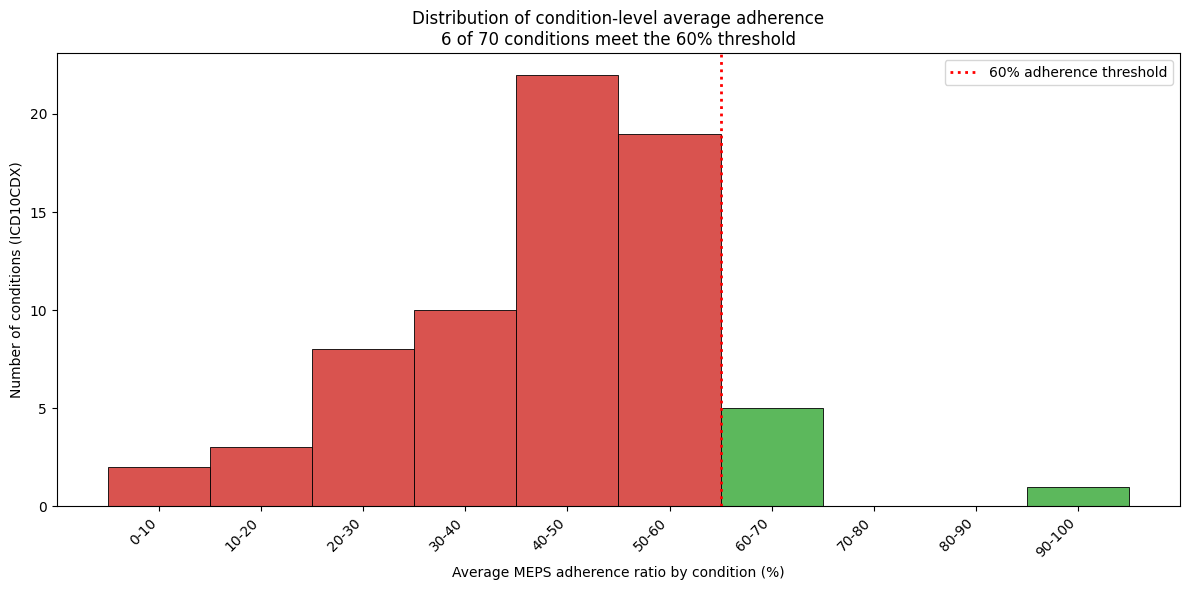

Adherent conditions (>=60%):


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
66,R26,ABNORMALITIES OF GAIT AND MOBILITY,98.630137
15,F20,SCHIZOPHRENIA,63.150685
13,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,62.365096
7,E03,OTHER HYPOTHYROIDISM,61.067229
31,I10,ESSENTIAL (PRIMARY) HYPERTENSION,60.692331
24,G25,OTHER EXTRAPYRAMIDAL AND MOVEMENT DISORDERS,60.352250


In [44]:
import matplotlib.pyplot as plt

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_condition["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_condition["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_condition)

ax.set_xlabel("Average MEPS adherence ratio by condition (%)")
ax.set_ylabel("Number of conditions (ICD10CDX)")
ax.set_title(
    f"Distribution of condition-level average adherence\n"
    f"{n_adherent} of {n_total} conditions meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_conditions = by_condition[
    by_condition["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent conditions (>={adherence_threshold}%):")
display(adherent_conditions)

Pearson correlation with meps_adherence_ratio
(ICD10CDX uses label encoding; interpret as a weak linear proxy only)



,pearson_r
ICD10CDX_code,-0.176972
TC1,0.130572
TC1S1,-0.018855



Eta-squared with meps_adherence_ratio
(better measure for categorical variables: share of variance explained)



,eta_squared
ICD10CDX,0.120675
TC1,0.107990
TC1S1,0.156917



Combined model: ICD10CDX + TC1 + TC1S1 together
  R-squared: 0.1680
  Adjusted R-squared: 0.1622


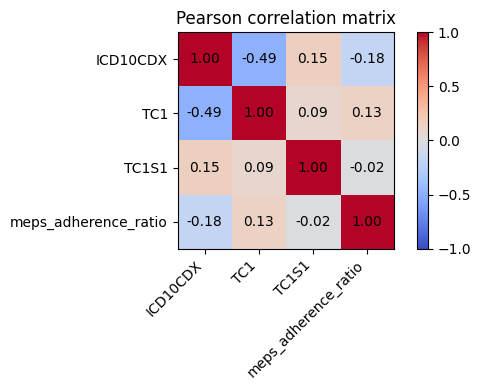

In [45]:
from sklearn.preprocessing import LabelEncoder

corr_df = grouped_merge_df.reset_index()[
    ["ICD10CDX", "TC1", "TC1S1", "meps_adherence_ratio"]
].dropna()

corr_df["ICD10CDX_code"] = LabelEncoder().fit_transform(corr_df["ICD10CDX"].astype(str))


def eta_squared(categorical, continuous):
    """Share of adherence variance explained by a categorical variable."""
    categories = categorical.astype(str)
    grand_mean = continuous.mean()
    ss_total = ((continuous - grand_mean) ** 2).sum()
    ss_between = sum(
        len(continuous[categories == cat]) * (continuous[categories == cat].mean() - grand_mean) ** 2
        for cat in categories.unique()
    )
    return ss_between / ss_total if ss_total > 0 else np.nan


pearson_corr = corr_df[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"]
].corr(method="pearson")

pearson_with_adherence = pearson_corr["meps_adherence_ratio"].drop("meps_adherence_ratio")

eta_results = pd.Series(
    {
        "ICD10CDX": eta_squared(corr_df["ICD10CDX"], corr_df["meps_adherence_ratio"]),
        "TC1": eta_squared(corr_df["TC1"], corr_df["meps_adherence_ratio"]),
        "TC1S1": eta_squared(corr_df["TC1S1"], corr_df["meps_adherence_ratio"]),
    },
    name="eta_squared",
)

X = pd.get_dummies(
    corr_df[["ICD10CDX", "TC1", "TC1S1"]].astype(str),
    drop_first=True,
).astype(float)
y = corr_df["meps_adherence_ratio"].values
X_with_intercept = np.column_stack([np.ones(len(X)), X.values])
coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
y_pred = X_with_intercept @ coeffs
ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
combined_r2 = 1 - ss_res / ss_tot
n, p = len(y), X.shape[1]
adj_r2 = 1 - (1 - combined_r2) * (n - 1) / (n - p - 1)

print("Pearson correlation with meps_adherence_ratio")
print("(ICD10CDX uses label encoding; interpret as a weak linear proxy only)\n")
display(pearson_with_adherence.to_frame("pearson_r"))

print("\nEta-squared with meps_adherence_ratio")
print("(better measure for categorical variables: share of variance explained)\n")
display(eta_results.to_frame())

print("\nCombined model: ICD10CDX + TC1 + TC1S1 together")
print(f"  R-squared: {combined_r2:.4f}")
print(f"  Adjusted R-squared: {adj_r2:.4f}")

heatmap_data = pearson_corr.loc[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
].rename(index={"ICD10CDX_code": "ICD10CDX"}, columns={"ICD10CDX_code": "ICD10CDX"})

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap_data.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f"{heatmap_data.iloc[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

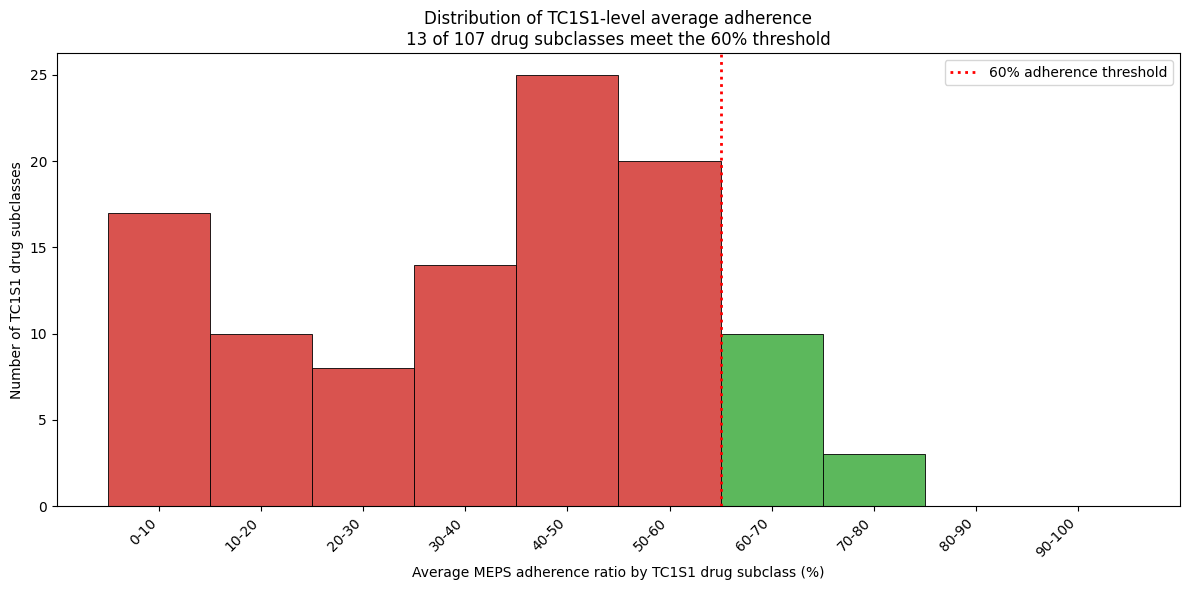

Adherent TC1S1 drug subclasses (>=60%):


,TC1,TC1S1,meps_adherence_ratio
29,40,51,79.452055
94,218,220,71.689498
65,97,288,70.442982
98,242,504,68.493151
32,40,55,63.428241
102,358,19,63.106243
26,40,47,62.634836
27,40,48,61.949442
64,97,103,60.860424
21,40,42,60.806529


In [46]:
by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_tc1s1["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_tc1s1["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_tc1s1)

ax.set_xlabel("Average MEPS adherence ratio by TC1S1 drug subclass (%)")
ax.set_ylabel("Number of TC1S1 drug subclasses")
ax.set_title(
    f"Distribution of TC1S1-level average adherence\n"
    f"{n_adherent} of {n_total} drug subclasses meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_tc1s1 = by_tc1s1[
    by_tc1s1["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent TC1S1 drug subclasses (>={adherence_threshold}%):")
display(adherent_tc1s1)

In [47]:
low_adherence_threshold = 10

by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 17 of 107


,TC1,TC1S1,meps_adherence_ratio
8,1,12,0.273973
2,1,2,2.243151
87,133,135,2.739726
7,1,11,2.880863
31,40,54,2.971549
9,1,13,3.152355
14,1,240,3.506849
70,113,-15,3.561644
3,1,4,3.711083
10,1,14,3.835616



ICD10CDX conditions with average adherence < 10%:
Count: 2 of 70


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
39,J32,CHRONIC SINUSITIS,6.469537
3,C44,OTHER AND UNSPECIFIED MALIGNANT NEOPLASM OF SKIN,9.996814


In [ ]:
demo_df = pd.read_excel(MEPS_DIR / "h243.xlsx")
demo_df.head()

In [ ]:
new_demo_df = demo_df[["DUPERSID","SEX","AGE22X","INSCOV22","POVCAT22","FAMINC22","PSTATS31","PSTATS53",
"PSTATS42","RACEV2X","BEGRFM31", "BEGRFY31", "BEGRFM42", "BEGRFY42", "BEGRFM53","BEGRFY53", "ENDRFM31", "ENDRFY31",
 "ENDRFM42", "ENDRFY42", "ENDRFM53",
"ENDRFY53"]]
new_demo_df.head()

In [50]:
##1 - Any private (Person had any private insurance coverage [including
#TRICARE/CHAMPVA] at any time during 2022)
#2 - Public only (Person had only public insurance coverage [excluding
#TRICARE/CHAMPVA] during 2022)
#3 - Uninsured (Person was uninsured during all of 2022)

In [51]:
#POVCAT22 - Poverty level

#1 is Poor
#5 is high income

#PSTATS31 - if val is 31 - deseaced 

In [52]:

new_grouped_merge_df = grouped_merge_df.merge(new_demo_df, on="DUPERSID", how="left")
new_grouped_merge_df.head()


,DUPERSID,RXDAYSUP,RXXP22X,RXSF22X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio,AGE22X,INSCOV22,POVCAT22,FAMINC22,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53
0,2460002101,60,555.100,0.000,JANUVIA,6027731,2019,358,99,E11,TYPE 2 DIABETES MELLITUS,60,365,16.438356,77,2,3,22000,11,11,11,2,10,2021,2,2022,7,2022,2,2022,7,2022,12,2022
1,2460002101,60,3.830,0.000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,365,16.438356,77,2,3,22000,11,11,11,2,10,2021,2,2022,7,2022,2,2022,7,2022,12,2022
2,2460002101,20,9.950,4.975,ED A-HIST,485025401,2019,122,132,J32,CHRONIC SINUSITIS,20,365,5.479452,77,2,3,22000,11,11,11,2,10,2021,2,2022,7,2022,2,2022,7,2022,12,2022
3,2460002101,60,3.830,0.000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,365,16.438356,77,2,3,22000,11,11,11,2,10,2021,2,2022,7,2022,2,2022,7,2022,12,2022
4,2460002101,60,24.555,0.000,ROSUVASTATIN,31722088390,2019,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,60,365,16.438356,77,2,3,22000,11,11,11,2,10,2021,2,2022,7,2022,2,2022,7,2022,12,2022


In [53]:
pstat_values = [31, 23, 24, 61]

pstat_df = new_grouped_merge_df.loc[
    new_grouped_merge_df["PSTATS31"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS53"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS42"].isin(pstat_values)
]

print(pstat_df.shape)
pstat_df.head()

(257, 34)


,DUPERSID,RXDAYSUP,RXXP22X,RXSF22X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio,AGE22X,INSCOV22,POVCAT22,FAMINC22,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53
114,2460192102,30,2.63,0.00,DONEPEZIL,43547027509,2022,57,313,F03,UNSPECIFIED DEMENTIA,30,365,8.219178,-1,1,4,41289,11,-1,31,1,8,2021,3,2022,-1,-1,3,2022,7,2022,-1,-1
252,2460469102,10,7.15,7.15,CEPHALEXIN,93314705,2019,1,9,J32,CHRONIC SINUSITIS,10,365,2.739726,-1,2,2,17109,11,-1,31,1,9,2021,3,2022,-1,-1,3,2022,8,2022,-1,-1
253,2460469102,90,328.10,141.00,WIXELA INHUB,378932032,2010,122,125,J43,EMPHYSEMA,90,365,24.657534,-1,2,2,17109,11,-1,31,1,9,2021,3,2022,-1,-1,3,2022,8,2022,-1,-1
254,2460469102,12,42.72,39.00,ALBUTEROL,66993001968,2010,122,125,J43,EMPHYSEMA,12,365,3.287671,-1,2,2,17109,11,-1,31,1,9,2021,3,2022,-1,-1,3,2022,8,2022,-1,-1
255,2460469102,30,6.00,6.00,PANTOPRAZOLE,378668977,2004,87,272,K21,GASTRO-ESOPHAGEAL REFLUX DISEASE,30,365,8.219178,-1,2,2,17109,11,-1,31,1,9,2021,3,2022,-1,-1,3,2022,8,2022,-1,-1


In [54]:
pstat_values = [31,11, 12, 13, 14, 21, 22, 31, 32, 33, 34, 35, 41, 42, 43, 44, 51, 74, -1  ]
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]

for val in pstat_values:
    mask = new_grouped_merge_df[pstat_cols].eq(val).any(axis=1)
    subset = new_grouped_merge_df.loc[mask, "total_valid_days"]
    print(f"PSTATS value {val} (rows where any PSTATS column == {val}): {len(subset)}")
    if len(subset) == 0:
        print("  No rows found.\n")
    else:
        display(subset.describe().to_frame(f"total_valid_days (PSTATS={val})"))
        print()

PSTATS value 31 (rows where any PSTATS column == 31): 257


,total_valid_days (PSTATS=31)
count,257.000000
mean,113.583658
std,89.917680
min,3.000000
25%,30.000000
50%,90.000000
75%,180.000000
max,365.000000



PSTATS value 11 (rows where any PSTATS column == 11): 25926


,total_valid_days (PSTATS=11)
count,25926.000000
mean,188.625511
std,123.004769
min,1.000000
25%,90.000000
50%,180.000000
75%,300.000000
max,365.000000



PSTATS value 12 (rows where any PSTATS column == 12): 32


...

,total_valid_days (PSTATS=44)
count,11.000000
mean,135.000000
std,89.190807
min,30.000000
25%,90.000000
50%,120.000000
75%,165.000000
max,365.000000



PSTATS value 51 (rows where any PSTATS column == 51): 9


,total_valid_days (PSTATS=51)
count,9.000000
mean,32.777778
std,22.857044
min,15.000000
25%,16.000000
50%,30.000000
75%,34.000000
max,90.000000



PSTATS value 74 (rows where any PSTATS column == 74): 0
  No rows found.

PSTATS value -1 (rows where any PSTATS column == -1): 235


,total_valid_days (PSTATS=-1)
count,235.000000
mean,95.740426
std,82.851251
min,5.000000
25%,30.000000
50%,90.000000
75%,90.000000
max,365.000000


In [ ]:
from datetime import date
import calendar

# Year this notebook targets. Change if you clone this notebook to a new year.
YEAR = 2022

# PSTATS codes per h251doc.pdf Tables 7 and 8 (pp. C-14 to C-20).
# The MEPS PSTATS taxonomy is stable across years; the same codes apply
# to 2020-2023 (COVID year 2020 just has more -1 nonresponse).
PSTATS_LABELS = {
    11: "In RU, responded in person (full round)",
    12: "Active military duty (no survey)",
    13: "Moved from RU, known whereabouts",
    14: "Moved from RU, unknown whereabouts",
    21: "Hospitalized (rounds 4-5)",
    22: "Left institution, rejoined community (rounds 4-5)",
    23: "Left institution then died (rounds 4-5)",
    24: "Died in health-care institution (rounds 4-5)",
    31: "Deceased",
    32: "Institutionalized (health care)",
    33: "Institutionalized (non-health care)",
    34: "Moved outside US",
    35: "Moved to military facility on active duty",
    36: "Went to institution (type unknown)",
    41: "Joined RU after reference period began",
    42: "Joined RU, not full-time military",
    43: "Unknown disposition / moved to unknown location",
    44: "Moved to another RU in same PSU",
    51: "Newborn in reference period",
    62: "Institutionalized prior to reference period (R3/1 only)",
    71: "Non-Key student living away, grades 1-12",
    72: "Dropped as ineligible non-Key",
    73: "Non-Key moved without Key member",
    74: "Moved as FT military, no Key member (ineligible round)",
    81: "FT student living away, non-response",
    -1: "Not in this round",
}

# Full-round participants: use the whole reference-period window as-is.
FULL_ROUND_STATUSES = {11, 13, 14, 22, 41, 42, 44, 51, 71}
# Ended-early participants (excluding death, handled separately below):
# reference period cuts off partway through the round.
STOP_STATUSES = {32, 33, 34, 35, 36}
# No coverage in this round (Inapplicable reference period, ineligible,
# or out-of-scope for the whole round).
NO_COVERAGE_STATUSES = {0, 12, 21, 24, 43, 62, 63, 64, 72, 73, 74, 81}


def _month_start(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), 1)


def _month_end(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), calendar.monthrange(int(year), int(month))[1])


def _round_detail(row, round_suffix):
    ps = int(row[f"PSTATS{round_suffix}"])
    return {
        "round": round_suffix,
        "pstats": ps,
        "pstats_label": PSTATS_LABELS.get(ps, f"Code {ps}"),
        "ref_start": _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"]),
        "ref_end": _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"]),
    }


def compute_reference_coverage(row, year=YEAR):
    """Return eligible days, coverage start/end, and notes from PSTATS + BEGRF/ENDRF.

    PSTATS == -1 means the person was not in that round (skip; no days added or removed).
    """
    year_start = date(year, 1, 1)
    year_end = date(year, 12, 31)

    active_rounds = [
        sfx for sfx in [31, 42, 53] if int(row[f"PSTATS{sfx}"]) != -1
    ]
    if not active_rounds:
        return 0, None, None, "not_in_any_round"

    if all(int(row[f"PSTATS{sfx}"]) == 11 for sfx in [31, 42, 53]):
        return 365, year_start, year_end, "full_year_all_rounds_11"

    coverage_start = None
    coverage_end = None
    notes = []

    for round_suffix in [31, 42, 53]:
        ps = int(row[f"PSTATS{round_suffix}"])
        beg = _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"])
        end = _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"])

        if ps == -1:
            notes.append(f"R{round_suffix}:not_in_round")
            continue
        if ps in NO_COVERAGE_STATUSES:
            notes.append(f"R{round_suffix}:no_coverage({ps})")
            continue

        if coverage_start is None:
            coverage_start = max(beg, year_start) if beg else year_start

        if ps in FULL_ROUND_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:active({ps})")
        elif ps == 31:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:death")
            break
        elif ps in STOP_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:stop({ps})")
            break
        else:
            # Unknown PSTATS code — leave a marker instead of silently including.
            notes.append(f"R{round_suffix}:UNCLASSIFIED({ps})")

    if coverage_start is None or coverage_end is None or coverage_end < coverage_start:
        return 0, None, None, "no_coverage"

    days = (coverage_end - coverage_start).days + 1
    return days, coverage_start, coverage_end, ";".join(notes)


person_demo = new_demo_df.drop_duplicates("DUPERSID").copy()
coverage_parts = person_demo.apply(compute_reference_coverage, axis=1, result_type="expand")
person_demo["total_days_supply"] = coverage_parts[0]
person_demo["ref_start_2022"] = coverage_parts[1]
person_demo["ref_end_2022"] = coverage_parts[2]
person_demo["coverage_notes"] = coverage_parts[3]

person_demo["in_round_31"] = person_demo["PSTATS31"] != -1
person_demo["in_round_42"] = person_demo["PSTATS42"] != -1
person_demo["in_round_53"] = person_demo["PSTATS53"] != -1

# Flag: person missed the last round (R5/3). Their denominator is truncated
# at the R4/2 interview date, but any fill captured at R4/2 with a long
# RXDAYSUP will keep adding days past that endpoint. Result: MPR can be
# biased upward (often pinned to 100% by the np.minimum cap below).
person_demo["r53_nonresponse"] = person_demo["PSTATS53"] == -1

person_demo["participation_type"] = np.select(
    [
        person_demo["coverage_notes"].eq("full_year_all_rounds_11"),
        person_demo["coverage_notes"].eq("not_in_any_round"),
        person_demo["coverage_notes"].str.contains("death", na=False),
        person_demo["coverage_notes"].str.contains("stop", na=False),
        person_demo["coverage_notes"].str.contains("no_coverage", na=False),
        person_demo["total_days_supply"].eq(0),
    ],
    [
        "full_year",
        "not_in_any_round",
        "ended_early_death",
        "ended_early_left_ru",
        "partial_no_survey",
        "no_coverage",
    ],
    default="partial_year",
)

reference_days_df = person_demo[
    [
        "DUPERSID",
        "in_round_31",
        "in_round_42",
        "in_round_53",
        "ref_start_2022",
        "ref_end_2022",
        "total_days_supply",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ]
]

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_demo_df = new_demo_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("Participation type counts:")
display(reference_days_df["participation_type"].value_counts().to_frame("persons"))

# Diagnostic: how many persons might have MPR biased upward by R5/3 nonresponse?
n_r53 = int(reference_days_df["r53_nonresponse"].sum())
print(f"\nR5/3 nonresponders flagged (PSTATS53 == -1): {n_r53} persons")
print("  Their denominator cuts off at the R4/2 interview date, but their")
print("  numerator (sum RXDAYSUP) can include fill days that extend past it.")
print("  Downstream: their MPR is at risk of being biased HIGH (often 100%).")

# Diagnostic: were any PSTATS codes in the data left UNCLASSIFIED after
# the extended classification above?
unclassified = person_demo[person_demo["coverage_notes"].str.contains("UNCLASSIFIED", na=False)]
if len(unclassified):
    print(f"\nWARNING: {len(unclassified)} persons still have unclassified PSTATS values.")
    print("  Inspect person_demo[person_demo['coverage_notes'].str.contains('UNCLASSIFIED')].")
else:
    print("\nAll PSTATS codes in this year's data were classified. ✓")

print("\nSample: full-year vs partial vs deceased")
display(
    reference_days_df[
        reference_days_df["participation_type"].isin(
            ["full_year", "ended_early_death", "partial_year", "partial_no_survey"]
        )
    ].head(10)
)


In [ ]:
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=[
        "total_days_supply",
        "ref_start_2022",
        "ref_end_2022",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ],
    errors="ignore",
)

new_grouped_merge_df = new_grouped_merge_df.merge(
    reference_days_df[
        [
            "DUPERSID",
            "total_days_supply",
            "ref_start_2022",
            "ref_end_2022",
            "participation_type",
            "coverage_notes",
            "r53_nonresponse",
        ]
    ],
    on="DUPERSID",
    how="left",
)

new_grouped_merge_df["total_valid_days"] = np.minimum(
    new_grouped_merge_df["total_valid_days"],
    new_grouped_merge_df["total_days_supply"],
)

new_grouped_merge_df["meps_adherence_ratio"] = np.where(
    new_grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    new_grouped_merge_df["total_valid_days"] / new_grouped_merge_df["total_days_supply"] * 100,
)

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_grouped_merge_df = new_grouped_merge_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("total_days_supply (PSTATS-based) summary:")
display(new_grouped_merge_df["total_days_supply"].describe().to_frame())

print("\nmeps_adherence_ratio after update:")
display(new_grouped_merge_df["meps_adherence_ratio"].describe().to_frame())

# Diagnostic: how much does R5/3-nonresponse bias inflate mean MPR?
overall = new_grouped_merge_df["meps_adherence_ratio"]
excl_r53 = new_grouped_merge_df.loc[
    ~new_grouped_merge_df["r53_nonresponse"].fillna(False), "meps_adherence_ratio"
]
n_r53_pairs = int(new_grouped_merge_df["r53_nonresponse"].fillna(False).sum())
print(f"\nR5/3-nonresponse impact on person-drug pairs: {n_r53_pairs} pairs affected")
print(f"  mean MPR overall:                    {overall.mean():.2f}%")
print(f"  mean MPR excluding R5/3 nonresponders: {excl_r53.mean():.2f}%")
print("  (If the excluded mean is materially lower, the flagged rows are")
print("   inflating the ratio via numerator-bleed past the truncated denominator.)")

print("\nCompare old flat 365 vs new PSTATS-based denominator:")
compare = reference_days_df.groupby("participation_type").agg(
    persons=("DUPERSID", "count"),
    mean_days=("total_days_supply", "mean"),
    min_days=("total_days_supply", "min"),
    max_days=("total_days_supply", "max"),
)
display(compare)


In [57]:
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP22X,RXSF22X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE22X,INSCOV22,POVCAT22,FAMINC22,RACEV2X,total_days_supply,ref_start_2022,ref_end_2022,participation_type,coverage_notes
0,2460002101,60,555.100,0.000,JANUVIA,6027731,2019,358,99,E11,TYPE 2 DIABETES MELLITUS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11
1,2460002101,60,3.830,0.000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11
2,2460002101,20,9.950,4.975,ED A-HIST,485025401,2019,122,132,J32,CHRONIC SINUSITIS,20,5.479452,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11
3,2460002101,60,3.830,0.000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11
4,2460002101,60,24.555,0.000,ROSUVASTATIN,31722088390,2019,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11


In [ ]:
rxname_df = pd.read_csv(MEPS_DIR / "unique_rxname_chronic_labeled_revised.csv")
rxname_df.head()

In [59]:
new_grouped_merge_df = pd.merge(new_grouped_merge_df, rxname_df, on="RXNAME", how="left")
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP22X,RXSF22X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE22X,INSCOV22,POVCAT22,FAMINC22,RACEV2X,total_days_supply,ref_start_2022,ref_end_2022,participation_type,coverage_notes,drug_condition_type,is_chronic
0,2460002101,60,555.100,0.000,JANUVIA,6027731,2019,358,99,E11,TYPE 2 DIABETES MELLITUS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
1,2460002101,60,3.830,0.000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
2,2460002101,20,9.950,4.975,ED A-HIST,485025401,2019,122,132,J32,CHRONIC SINUSITIS,20,5.479452,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,flare_up,0.0
3,2460002101,60,3.830,0.000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
4,2460002101,60,24.555,0.000,ROSUVASTATIN,31722088390,2019,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0


In [61]:
#new_grouped_merge_df.drop(columns = ["drug_condition_type_y","is_chronic_y"],inplace = True)

In [62]:
new_grouped_merge_df["is_chronic"].value_counts()

is_chronic
1.0    19299
0.0     6077
Name: count, dtype: int64

In [64]:
new_grouped_merge_df = new_grouped_merge_df[new_grouped_merge_df["is_chronic"]==1]
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP22X,RXSF22X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE22X,INSCOV22,POVCAT22,FAMINC22,RACEV2X,total_days_supply,ref_start_2022,ref_end_2022,participation_type,coverage_notes,drug_condition_type,is_chronic
0,2460002101,60,555.100000,0.000000,JANUVIA,6027731,2019,358,99,E11,TYPE 2 DIABETES MELLITUS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
1,2460002101,60,3.830000,0.000000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
3,2460002101,60,3.830000,0.000000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
4,2460002101,60,24.555000,0.000000,ROSUVASTATIN,31722088390,2019,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
6,2460006101,150,19.656667,1.316667,LOSARTAN POT,68382013710,2020,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,150,41.095890,64,2,1,5000,1,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0


In [ ]:
by_drug_class = (
    new_grouped_merge_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
48,115,119,80.388128
16,40,51,79.452055
41,97,288,71.860407
57,242,504,68.493151
61,358,194,64.603496
18,40,55,64.007444
59,358,19,63.427335
13,40,47,63.036299
14,40,48,62.246160
40,97,103,61.215397


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
44,105,460,14.392018
28,57,312,17.260274
5,20,25,24.657534
6,20,403,24.725649
38,97,98,28.668709
35,87,91,30.000000
0,-15,-1,30.000000
30,57,516,31.872146
53,133,247,33.297827
37,87,355,34.750414


In [65]:
low_adherence_threshold = 20

by_tc1s1 = (
    new_grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    new_grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 20%:
Count: 2 of 63


,TC1,TC1S1,meps_adherence_ratio
44,105,460,14.392018
28,57,312,17.260274



ICD10CDX conditions with average adherence < 20%:
Count: 0 of 69


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio


In [ ]:
top_20_least_adherent = (
    new_grouped_merge_df
    .dropna(subset=["meps_adherence_ratio"])
    .groupby(["ICD10CDX", "ICD10CDX_LABEL", "RXNAME"], as_index=False)
    .agg(
        meps_adherence_ratio=("meps_adherence_ratio", "mean"),
        patient_drug_pairs=("DUPERSID", "count"),
    )
    .nsmallest(20, "meps_adherence_ratio")
    .sort_values("meps_adherence_ratio", ascending=True)
    .reset_index(drop=True)
)

print("Top 20 least adherent conditions with drug name:")
display(top_20_least_adherent)

Top 20 least adherent conditions with drug name:


,ICD10CDX,ICD10CDX_LABEL,RXNAME,meps_adherence_ratio,patient_drug_pairs
0,Z79,LONG TERM (CURRENT) DRUG THERAPY,METOPROL TAR,0.547945,1
1,N40,BENIGN PROSTATIC HYPERPLASIA,ANTICHOLINERGICS/ANTISPASMODICS,1.369863,1
2,K50,CROHN'S DISEASE [REGIONAL ENTERITIS],ANTICHOLINERGICS/ANTISPASMODICS,1.917808,1
3,H40,GLAUCOMA,NITROGLYCERN,2.191781,1
4,I10,ESSENTIAL (PRIMARY) HYPERTENSION,NITROGLYCERN,2.191781,1
5,I10,ESSENTIAL (PRIMARY) HYPERTENSION,INSULIN,3.561644,1
6,J32,CHRONIC SINUSITIS,BACLOFEN,3.835616,1
7,I20,ANGINA PECTORIS,NITROGLYCERN,4.109589,4
8,J42,UNSPECIFIED CHRONIC BRONCHITIS,BUDESONIDE,4.109589,1
9,F41,OTHER ANXIETY DISORDERS,BENZODIAZEPINE ANTICONVULSANTS,4.246575,2


In [66]:
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP22X,RXSF22X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE22X,INSCOV22,POVCAT22,FAMINC22,RACEV2X,total_days_supply,ref_start_2022,ref_end_2022,participation_type,coverage_notes,drug_condition_type,is_chronic
0,2460002101,60,555.100000,0.000000,JANUVIA,6027731,2019,358,99,E11,TYPE 2 DIABETES MELLITUS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
1,2460002101,60,3.830000,0.000000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
3,2460002101,60,3.830000,0.000000,FLUTICASONE,54327099,2019,133,247,J32,CHRONIC SINUSITIS,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
4,2460002101,60,24.555000,0.000000,ROSUVASTATIN,31722088390,2019,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,60,16.438356,77,2,3,22000,2,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0
6,2460006101,150,19.656667,1.316667,LOSARTAN POT,68382013710,2020,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,150,41.095890,64,2,1,5000,1,365,2022-01-01,2022-12-31,full_year,full_year_all_rounds_11,chronic,1.0


In [ ]:
delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=["DLAYPM42", "DLAYCA42"], errors="ignore"
).merge(delay_df, on="DUPERSID", how="left")

model_df = new_grouped_merge_df[[
    'DUPERSID','RXNAME','ICD10CDX','ICD10CDX_LABEL',
    'AGE22X','SEX','INSCOV22','POVCAT22','FAMINC22','RACEV2X',
    'RXSF22X','RXXP22X',
    'DLAYPM42','DLAYCA42','meps_adherence_ratio',
]].copy()

# Cost cols: NaN -> 0, clip negatives (MEPS RXSF/RXXP should be >= 0)
model_df['RXSF22X'] = pd.to_numeric(model_df['RXSF22X'], errors='coerce').fillna(0).clip(lower=0)
model_df['RXXP22X'] = pd.to_numeric(model_df['RXXP22X'], errors='coerce').fillna(0).clip(lower=0)

model_df = model_df.rename(columns={'RXSF22X':'RXSF_PATIENT','RXXP22X':'RXXP_TOTAL'})
model_df.head()

In [ ]:
model_df.head()

In [ ]:
model_df['is_adherent'] = np.where(model_df['meps_adherence_ratio'] >= 60, 1, 0)

neg_mask = model_df.select_dtypes(include="number").lt(0).any(axis=1)
n_dropped = int(neg_mask.sum())
model_df = model_df.loc[~neg_mask].copy()
print(f"Dropped RXNDC earlier; dropped {n_dropped} rows with negatives; remaining {len(model_df)}")

model_df.head()

In [ ]:
# Drop RXNDC (if still present) and remove any row with a negative numeric value
model_df = model_df.drop(columns=["RXNDC"], errors="ignore")

feature_cols = [
    c for c in model_df.columns
    if c not in {"DUPERSID", "RXNAME", "ICD10CDX", "ICD10CDX_LABEL"}
]
for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("Negative counts BEFORE drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))

neg_mask = model_df[feature_cols].lt(0).any(axis=1)
n_before = len(model_df)
model_df = model_df.loc[~neg_mask].copy()

print(f"\nDropped {int(neg_mask.sum())} rows with negatives ({n_before} -> {len(model_df)})")
print("Negative counts AFTER drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))
model_df.head()

In [ ]:
model_df.describe()

In [ ]:
model_df['INSCOV22'].unique()

In [ ]:
# Insurance: 3 dummies matching MEPS INSCOV22 codes (1=private, 2=public-only, 3=uninsured)
model_df['INSCOV_PRIVATE'] = (model_df['INSCOV22'] == 1).astype(int)
model_df['INSCOV_PUBLIC'] = (model_df['INSCOV22'] == 2).astype(int)
model_df['INSCOV_UNINSURED'] = (model_df['INSCOV22'] == 3).astype(int)
model_df = model_df.drop(columns=['INSCOV22'])
model_df.head()

In [ ]:
model_df['MALE'] = np.where(model_df['SEX']==1, 1, 0)
model_df['FEMALE'] = np.where(model_df['SEX']==2, 1, 0)
model_df.drop(columns = ['SEX'],inplace = True)
model_df.head()

In [ ]:
model_df['RACEV2X'].unique()


model_df['WHITE'] = np.where(model_df['RACEV2X']==1, 1, 0)
model_df['BLACK'] = np.where(model_df['RACEV2X']==2, 1, 0)
model_df['AMER_INDIAN'] = np.where(model_df['RACEV2X']==3, 1, 0)
model_df['ASIAN_INDIAN'] = np.where(model_df['RACEV2X']==4, 1, 0)
model_df['CHINESE'] = np.where(model_df['RACEV2X']==5, 1, 0)
model_df['FILIPINO'] = np.where(model_df['RACEV2X']==6, 1, 0)


# 1 WHITE - NO OTHER RACE REPORTED 14,118 250,268,262
# 2 BLACK - NO OTHER RACE REPORTED 2,666 44,558,431
# 3 AMER INDIAN/ALASKA NATIVE-NO OTHER RACE 163 2,838,974
# 4 ASIAN INDIAN - NO OTHER RACE REPORTED 380 7,055,957
# 5 CHINESE - NO OTHER RACE REPORTED 272 5,400,356
# 6 FILIPINO - NO OTHER RACE REPORTED 174 3,110,110
# 10 OTH ASIAN/NATV HAWAIIAN/PACFC ISL-NO OTH 422 7,436,055
# 12 MULTIPLE RACES REPORTED 
model_df.drop(columns = ['RACEV2X'],inplace = True)
model_df.head()

In [ ]:
# DLAYPM42 / DLAYCA42 may already be dropped — pull them back from demo_df if needed
if "DLAYPM42" not in model_df.columns or "DLAYCA42" not in model_df.columns:
    delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
    model_df = model_df.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
        delay_df, on="DUPERSID", how="left"
    )

# 1=YES delayed for cost, 2=NO
model_df["PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 1, 1, 0)
model_df["NO_PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 2, 1, 0)

model_df["CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 1, 1, 0)
model_df["NO_CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 2, 1, 0)

model_df.drop(columns=["DLAYPM42", "DLAYCA42"], inplace=True)
model_df.head()

In [ ]:
# POVCAT22 may already be dropped — pull it back from demo_df if needed
if "POVCAT22" not in model_df.columns:
    pov_df = demo_df[["DUPERSID", "POVCAT22"]].drop_duplicates("DUPERSID")
    model_df = model_df.merge(pov_df, on="DUPERSID", how="left")

# 1=Poor ... 5=High income
model_df["POV_POOR"] = np.where(model_df["POVCAT22"] == 1, 1, 0)
model_df["POV_NEAR_POOR"] = np.where(model_df["POVCAT22"] == 2, 1, 0)
model_df["POV_LOW"] = np.where(model_df["POVCAT22"] == 3, 1, 0)
model_df["POV_MIDDLE"] = np.where(model_df["POVCAT22"] == 4, 1, 0)
model_df["POV_HIGH"] = np.where(model_df["POVCAT22"] == 5, 1, 0)

model_df.drop(columns=["POVCAT22"], inplace=True)
model_df.head()

In [ ]:
model_df["ICD10CDX_LABEL"].nunique()

In [ ]:
model_df["RXNAME"].value_counts().tolist()

In [ ]:
rx_counts = model_df["RXNAME"].value_counts(dropna=False)
n_once = int((rx_counts >9).sum())

print(f"unique RXNAME: {rx_counts.shape[0]}")
print(f"RXNAME appearing exactly once: {n_once}")
print(f"share of unique names: {100 * n_once / rx_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
rx_counts[rx_counts >9 ]

In [ ]:
# Diagnostic: how many rows/RXNAMEs we WOULD have kept at a >=10 threshold
# (kept for reference — we actually keep ALL drugs; the >=10 filter was too aggressive)
rx_counts = model_df['RXNAME'].value_counts()
keep_names = rx_counts[rx_counts >= 10].index
print(f"total pair-level rows: {len(model_df):,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"RXNAMEs with >=10 fills: {len(keep_names):,}")
print(f"rows if we HAD applied >=10 filter: {int(model_df['RXNAME'].isin(keep_names).sum()):,} "
      f"({int(model_df['RXNAME'].isin(keep_names).mean()*100)}% retained)")
print("Not filtering — cell 90 will one-hot all RXNAMEs.")

In [ ]:
model_df["ICD10CDX"].nunique()

In [ ]:
model_df["ICD10CDX"].value_counts()

In [ ]:
icd_counts = model_df["ICD10CDX"].value_counts(dropna=False)
n_once = int((icd_counts >9).sum())

print(f"unique ICD10CDX: {icd_counts.shape[0]}")
print(f"ICD10CDX appearing exactly once: {n_once}")
print(f"share of unique codes: {100 * n_once / icd_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
icd_counts[icd_counts >9]

In [ ]:
# model_df is now fully assembled by cells 68-78 with:
#   RX cost split (RXSF_PATIENT, RXXP_TOTAL), 3-dummy insurance, SEX/RACE/POV/DLAY dummies,
#   raw RXNAME + ICD10CDX (cell 90 will one-hot them at person level).
# Just drop the label column and print a summary.

model_df = model_df.drop(columns=['ICD10CDX_LABEL'], errors='ignore')

print(f"pair-level rows: {len(model_df):,}")
print(f"unique patients: {model_df['DUPERSID'].nunique():,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"unique ICD10CDX: {model_df['ICD10CDX'].nunique():,}")
print(
    f"insurance rows: private={int(model_df['INSCOV_PRIVATE'].sum()):,} "
    f"public={int(model_df['INSCOV_PUBLIC'].sum()):,} "
    f"uninsured={int(model_df['INSCOV_UNINSURED'].sum()):,}"
)
model_df.head()

In [ ]:
# --- One-hot drugs + conditions (0/1), then 1 row per patient ---
rx_dummies = pd.get_dummies(model_df["RXNAME"], prefix="RX").astype(int)
icd_dummies = pd.get_dummies(model_df["ICD10CDX"], prefix="ICD").astype(int)

pair_df = pd.concat(
    [model_df.drop(columns=["RXNAME", "ICD10CDX"]), rx_dummies, icd_dummies],
    axis=1,
)

rx_cols = [c for c in pair_df.columns if c.startswith("RX_")]
icd_cols = [c for c in pair_df.columns if c.startswith("ICD_")]
COST_COLS = {"RXSF_PATIENT", "RXXP_TOTAL"}
person_cols = [
    c for c in pair_df.columns
    if c not in {"DUPERSID", "meps_adherence_ratio"} | COST_COLS
    and c not in rx_cols and c not in icd_cols
]

agg = {c: "max" for c in person_cols + rx_cols + icd_cols}
agg["meps_adherence_ratio"] = "mean"
agg["RXSF_PATIENT"] = "sum"  # total patient-paid dollars across a patient's fills
agg["RXXP_TOTAL"]   = "sum"  # total drug expenditure across a patient's fills

model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)

# fraction of drug bill patient paid out-of-pocket (0..1). NaN-safe.
model_df["PATIENT_COST_SHARE"] = np.where(
    model_df["RXXP_TOTAL"] > 0,
    model_df["RXSF_PATIENT"] / model_df["RXXP_TOTAL"],
    0.0,
)
model_df = model_df.drop(columns=["RXSF_PATIENT", "RXXP_TOTAL"])

model_df["is_adherent"] = np.where(model_df["meps_adherence_ratio"] >= 60, 1, 0)

print(f"patient-level rows: {len(model_df):,} (should equal unique DUPERSID)")
print(f"RX dummy cols: {len(rx_cols)} | ICD dummy cols: {len(icd_cols)}")
print(f"is_adherent value counts:\n{model_df['is_adherent'].value_counts()}")
print("PATIENT_COST_SHARE describe:")
print(model_df['PATIENT_COST_SHARE'].describe().round(3))
model_df.head()

In [ ]:
# Counts + examples: patients with >1 drug and/or >1 condition
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]

model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

n_multi_drug = int((model_df["n_drugs"] > 1).sum())
n_multi_cond = int((model_df["n_conditions"] > 1).sum())
n_both = int(((model_df["n_drugs"] > 1) & (model_df["n_conditions"] > 1)).sum())

print(f"patients total: {len(model_df):,}")
print(f"patients with >1 drug: {n_multi_drug:,}")
print(f"patients with >1 condition: {n_multi_cond:,}")
print(f"patients with >1 drug AND >1 condition: {n_both:,}")

print("\nn_drugs distribution:")
display(model_df["n_drugs"].value_counts().sort_index().head(15))
print("\nn_conditions distribution:")
display(model_df["n_conditions"].value_counts().sort_index().head(15))

# Example patients
example_cols = ["DUPERSID", "n_drugs", "n_conditions", "meps_adherence_ratio", "is_adherent"]

print("\n--- examples: >1 drug ---")
multi_drug_ex = model_df.loc[model_df["n_drugs"] > 1, example_cols].head(5)
display(multi_drug_ex)
for _, row in multi_drug_ex.iterrows():
    pid = row["DUPERSID"]
    drugs = [c.replace("RX_", "") for c in rx_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: drugs={drugs}")

print("\n--- examples: >1 condition ---")
multi_cond_ex = model_df.loc[model_df["n_conditions"] > 1, example_cols].head(5)
display(multi_cond_ex)
for _, row in multi_cond_ex.iterrows():
    pid = row["DUPERSID"]
    conds = [c.replace("ICD_", "") for c in icd_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: conditions={conds}")

In [ ]:
# Random Forest: predict is_adherent (hyperparameter tuning)
# Edit PARAM_GRID / CV settings below if you want to change the search.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
SCORING = "f1"
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage
    "n_drugs",
    "n_conditions",
]

X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df["is_adherent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X shape: {X.shape} | train: {X_train.shape[0]} | test: {X_test.shape[0]}")
print(f"class balance (full):\n{y.value_counts(normalize=True).round(3)}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID.values()])} x {CV_FOLDS} folds")

In [ ]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import f1_score
import time

param_list = list(ParameterGrid(PARAM_GRID))
n_combos = len(param_list)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting grid search: {n_combos} param combos x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits\n")

best_score = -np.inf
best_params = None
results = []
t0 = time.perf_counter()

for i, params in enumerate(param_list, start=1):
    fold_scores = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = rf.predict(X_train.iloc[val_idx])
        fold_scores.append(f1_score(y_train.iloc[val_idx], pred))

    mean_score = float(np.mean(fold_scores))
    results.append({**params, "mean_f1": mean_score})

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

    elapsed = time.perf_counter() - t0
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (n_combos - i)
    print(
        f"[{i}/{n_combos}] mean_f1={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_f1={best_score:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params:", best_params)
print(f"Best CV f1: {best_score:.4f}")

# Refit best model on full training set, evaluate on holdout test
best_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not adherent", "adherent"]).plot(ax=ax, cmap="Blues")
ax.set_title("Random Forest — is_adherent")
plt.tight_layout()
plt.show()

In [ ]:
# Same grid search, tuned on ROC-AUC (with progress + ETA)
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import time

param_list = list(ParameterGrid(PARAM_GRID))
n_combos = len(param_list)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting grid search (AUC): {n_combos} param combos x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits\n")

best_score_auc = -np.inf
best_params_auc = None
results_auc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list, start=1):
    fold_scores = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        proba = rf.predict_proba(X_train.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train.iloc[val_idx], proba))

    mean_score = float(np.mean(fold_scores))
    results_auc.append({**params, "mean_auc": mean_score})

    if mean_score > best_score_auc:
        best_score_auc = mean_score
        best_params_auc = params

    elapsed = time.perf_counter() - t0
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (n_combos - i)
    print(
        f"[{i}/{n_combos}] mean_auc={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_auc={best_score_auc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (AUC):", best_params_auc)
print(f"Best CV AUC: {best_score_auc:.4f}")

# Refit best AUC model on full training set, evaluate on holdout test
best_rf_auc = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params_auc)
best_rf_auc.fit(X_train, y_train)
y_pred_auc = best_rf_auc.predict(X_test)
y_proba_auc = best_rf_auc.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba_auc):.4f}")
print("\nClassification report (test set, AUC-tuned model):")
print(classification_report(y_test, y_pred_auc, digits=3))

cm_auc = confusion_matrix(y_test, y_pred_auc)
print("Confusion matrix (test set):")
print(cm_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_auc, display_labels=["not adherent", "adherent"]).plot(
    ax=axes[0], cmap="Blues"
)
axes[0].set_title("RF (AUC-tuned) — confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba_auc, ax=axes[1])
axes[1].set_title("RF (AUC-tuned) — ROC curve")
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance: Gini (RF impurity decrease) + SHAP
# Uses AUC-tuned model if available, else F1-tuned model.

import shap

model_for_imp = best_rf_auc if "best_rf_auc" in dir() else best_rf
model_label = "AUC-tuned" if "best_rf_auc" in dir() and model_for_imp is best_rf_auc else "F1-tuned"

TOP_N = 20  # edit: how many features to show

gini_imp = (
    pd.Series(model_for_imp.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N} ({model_label} RF)")
display(gini_imp.head(TOP_N).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N} features — Gini ({model_label})")
plt.tight_layout()
plt.show()

In [ ]:
# SHAP values (TreeExplainer) — mean |SHAP| ranking + beeswarm
# Uses a sample of the training set for speed; raise SHAP_SAMPLE if you want more precision.

SHAP_SAMPLE = 500  # edit: number of rows for SHAP

X_shap = X_train.sample(n=min(SHAP_SAMPLE, len(X_train)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model_for_imp)
shap_values = explainer.shap_values(X_shap)

# Binary RF: shap_values is often [class0, class1] or a 3D array depending on shap version
if isinstance(shap_values, list):
    shap_pos = shap_values[1]  # class 1 = adherent
elif getattr(shap_values, "ndim", 0) == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

mean_abs_shap = (
    pd.Series(np.abs(shap_pos).mean(axis=0), index=X_shap.columns)
    .sort_values(ascending=False)
)

print(f"SHAP mean |value| — top {TOP_N} ({model_label} RF, n={len(X_shap)})")
display(mean_abs_shap.head(TOP_N).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N} features — SHAP ({model_label})")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent):")
shap.summary_plot(shap_pos, X_shap, max_display=TOP_N, show=False)
plt.title(f"SHAP beeswarm — {model_label}")
plt.tight_layout()
plt.show()

In [ ]:
# F1-tuned RF — Gini feature importance
TOP_N_F1 = 20  # edit

gini_imp_f1 = (
    pd.Series(best_rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N_F1} (F1-tuned RF)")
print("Best F1 params:", best_params)
display(gini_imp_f1.head(TOP_N_F1).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp_f1.head(TOP_N_F1).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N_F1} features — Gini (F1-tuned)")
plt.tight_layout()
plt.show()

In [ ]:
# F1-tuned RF — SHAP feature importance
import shap

SHAP_SAMPLE_F1 = 500  # edit

X_shap_f1 = X_train.sample(n=min(SHAP_SAMPLE_F1, len(X_train)), random_state=RANDOM_STATE)

explainer_f1 = shap.TreeExplainer(best_rf)
shap_values_f1 = explainer_f1.shap_values(X_shap_f1)

if isinstance(shap_values_f1, list):
    shap_pos_f1 = shap_values_f1[1]
elif getattr(shap_values_f1, "ndim", 0) == 3:
    shap_pos_f1 = shap_values_f1[:, :, 1]
else:
    shap_pos_f1 = shap_values_f1

mean_abs_shap_f1 = (
    pd.Series(np.abs(shap_pos_f1).mean(axis=0), index=X_shap_f1.columns)
    .sort_values(ascending=False)
)

print(f"SHAP mean |value| — top {TOP_N_F1} (F1-tuned RF, n={len(X_shap_f1)})")
display(mean_abs_shap_f1.head(TOP_N_F1).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap_f1.head(TOP_N_F1).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N_F1} features — SHAP (F1-tuned)")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent, F1-tuned):")
shap.summary_plot(shap_pos_f1, X_shap_f1, max_display=TOP_N_F1, show=False)
plt.title("SHAP beeswarm — F1-tuned")
plt.tight_layout()
plt.show()

In [ ]:
# RF with n_drugs + n_conditions included as features
# (still drops meps_adherence_ratio to avoid leakage)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, ParameterGrid, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
import time

# Ensure count columns exist on patient-level model_df
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]
model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

PARAM_GRID_NC = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols_nc = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage — still dropped
    # n_drugs / n_conditions KEPT as features
]

X_nc = model_df.drop(columns=[c for c in drop_cols_nc if c in model_df.columns])
y_nc = model_df["is_adherent"]

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_nc, y_nc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_nc
)

print("Features include n_drugs / n_conditions:", 
      "n_drugs" in X_nc.columns and "n_conditions" in X_nc.columns)
print(f"X_nc shape: {X_nc.shape} | train: {X_train_nc.shape[0]} | test: {X_test_nc.shape[0]}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID_NC.values()])} x {CV_FOLDS} folds")

In [ ]:
# Grid search (F1) for RF with n_drugs + n_conditions — progress + ETA
param_list_nc = list(ParameterGrid(PARAM_GRID_NC))
n_combos_nc = len(param_list_nc)
cv_nc = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(
    f"Starting grid search (F1, with n_drugs/n_conditions): "
    f"{n_combos_nc} combos x {CV_FOLDS} folds = {n_combos_nc * CV_FOLDS} fits\n"
)

best_score_nc = -np.inf
best_params_nc = None
results_nc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list_nc, start=1):
    fold_scores = []
    for train_idx, val_idx in cv_nc.split(X_train_nc, y_train_nc):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train_nc.iloc[train_idx], y_train_nc.iloc[train_idx])
        pred = rf.predict(X_train_nc.iloc[val_idx])
        fold_scores.append(f1_score(y_train_nc.iloc[val_idx], pred))

    mean_score = float(np.mean(fold_scores))
    results_nc.append({**params, "mean_f1": mean_score})

    if mean_score > best_score_nc:
        best_score_nc = mean_score
        best_params_nc = params

    elapsed = time.perf_counter() - t0
    remaining = (elapsed / i) * (n_combos_nc - i)
    print(
        f"[{i}/{n_combos_nc}] mean_f1={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_f1={best_score_nc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (with n_drugs/n_conditions):", best_params_nc)
print(f"Best CV f1: {best_score_nc:.4f}")

best_rf_nc = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params_nc)
best_rf_nc.fit(X_train_nc, y_train_nc)
y_pred_nc = best_rf_nc.predict(X_test_nc)

print("\nClassification report (test set, with n_drugs/n_conditions):")
print(classification_report(y_test_nc, y_pred_nc, digits=3))

cm_nc = confusion_matrix(y_test_nc, y_pred_nc)
print("Confusion matrix (test set):")
print(cm_nc)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_nc, display_labels=["not adherent", "adherent"]
).plot(ax=ax, cmap="Blues")
ax.set_title("RF (F1) — with n_drugs & n_conditions")
plt.tight_layout()
plt.show()

In [ ]:
# Grid search (AUC) for RF with n_drugs + n_conditions — progress + ETA
from sklearn.metrics import roc_auc_score, RocCurveDisplay

param_list_nc = list(ParameterGrid(PARAM_GRID_NC))
n_combos_nc = len(param_list_nc)
cv_nc = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(
    f"Starting grid search (AUC, with n_drugs/n_conditions): "
    f"{n_combos_nc} combos x {CV_FOLDS} folds = {n_combos_nc * CV_FOLDS} fits\n"
)

best_score_nc_auc = -np.inf
best_params_nc_auc = None
results_nc_auc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list_nc, start=1):
    fold_scores = []
    for train_idx, val_idx in cv_nc.split(X_train_nc, y_train_nc):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train_nc.iloc[train_idx], y_train_nc.iloc[train_idx])
        proba = rf.predict_proba(X_train_nc.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train_nc.iloc[val_idx], proba))

    mean_score = float(np.mean(fold_scores))
    results_nc_auc.append({**params, "mean_auc": mean_score})

    if mean_score > best_score_nc_auc:
        best_score_nc_auc = mean_score
        best_params_nc_auc = params

    elapsed = time.perf_counter() - t0
    remaining = (elapsed / i) * (n_combos_nc - i)
    print(
        f"[{i}/{n_combos_nc}] mean_auc={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_auc={best_score_nc_auc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (AUC, with n_drugs/n_conditions):", best_params_nc_auc)
print(f"Best CV AUC: {best_score_nc_auc:.4f}")

best_rf_nc_auc = RandomForestClassifier(
    random_state=RANDOM_STATE, n_jobs=-1, **best_params_nc_auc
)
best_rf_nc_auc.fit(X_train_nc, y_train_nc)
y_pred_nc_auc = best_rf_nc_auc.predict(X_test_nc)
y_proba_nc_auc = best_rf_nc_auc.predict_proba(X_test_nc)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test_nc, y_proba_nc_auc):.4f}")
print("\nClassification report (test set, AUC-tuned with n_drugs/n_conditions):")
print(classification_report(y_test_nc, y_pred_nc_auc, digits=3))

cm_nc_auc = confusion_matrix(y_test_nc, y_pred_nc_auc)
print("Confusion matrix (test set):")
print(cm_nc_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_nc_auc, display_labels=["not adherent", "adherent"]
).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("RF (AUC) — with n_drugs & n_conditions")
RocCurveDisplay.from_predictions(y_test_nc, y_proba_nc_auc, ax=axes[1])
axes[1].set_title("ROC — with n_drugs & n_conditions")
plt.tight_layout()
plt.show()